<a href="https://colab.research.google.com/github/Shambhaviadhikari/PythonClass/blob/main/Gutenberg_Book_Classifier_(Fall_2024)_%5BG37903602%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instructions

In this exercise, we will practice Natural Language Processing by performing classification on book texts.

We will train a model on a corpus consisting of a handful of books. Then for a given passage of text, we will use the model to predict which book that text is most likely to come from.

Many steps have been done for you, but there are ten "Tasks" you will need to complete along the way.
  



## Setup

In [ ]:
%%capture
!pip install gutenbergpy

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Data Loading


Here is a helper function to load book text from [Project Gutenberg](https://gutenberg.org/browse/scores/top):

In [ ]:
from gutenbergpy.textget import get_text_by_id, strip_headers
import re


def get_book(book_id=2701):
    """Fetches the text of a book given its gutenberg identifier.

        For a list of books and identifiers, see: https://gutenberg.org/browse/scores/top.

        Performs light touch preprocessing, just in hopes of getting some readable text.

        Returns the text as a string.
    """
    print("FETCHING BOOK:", book_id)
    raw_book = get_text_by_id(book_id) # with headers
    clean_book = strip_headers(raw_book) # without headers
    # we are dealing with bytes at this point

    # remove weird unicode characters:
    clean_book = clean_book.decode("utf-8").encode("ascii", "ignore")

    text = str(clean_book)
    text = text.replace("\\n", " ").replace("\\", "")

    # remove extra whitespace:
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


book = get_book(64317)
print(type(book), len(book))
book[0:1000]
#book[-1000:]

FETCHING BOOK: 64317
<class 'str'> 263394


"b' The Great Gatsby by F. Scott Fitzgerald Table of Contents I II III IV V VI VII VIII IX Once again to Zelda Then wear the gold hat, if that will move her; If you can bounce high, bounce for her too, Till she cry Lover, gold-hatted, high-bouncing lover, I must have you! Thomas Parke dInvilliers I In my younger and more vulnerable years my father gave me some advice that Ive been turning over in my mind ever since. Whenever you feel like criticizing anyone, he told me, just remember that all the people in this world havent had the advantages that youve had. He didnt say any more, but weve always been unusually communicative in a reserved way, and I understood that he meant a great deal more than that. In consequence, Im inclined to reserve all judgements, a habit that has opened up many curious natures to me and also made me the victim of not a few veteran bores. The abnormal mind is quick to detect and attach itself to this quality when it appears in a normal person, and so it came a

### Book Selection [Task 0]

Choose your own set of three books available from Project Gutenberg, and note the identifiers.

Here is a curated list of examples:

  + 16: Peter Pan
  + 55: Wizard of Oz
  + 1062: Edgar Allen Poe Collection
  + 1342: Pride and Prejudice
  + 1437: Little Women
  + 1513: Romeo and Juliet
  + 1727: The Odyssey
  + 64317: Great Gatsby
  
  + 67098: Winnie the Pooh

Or reference the complete list here:
https://gutenberg.org/browse/scores/top


Update the `book_records` variable below, as desired, to include your chosen book names and identifiers:

In [ ]:
from pandas import DataFrame, Series

book_records = [
    {"book_id": 16, "book_name": "PETER_PAN"},
    {"book_id": 55, "book_name": "WIZARD_OZ"},
    {"book_id": 67098, "book_name": "WINNIE_POOH"},
    # choose your own books of interest! three to five should be fine
]
books_df = DataFrame(book_records)
books_df.index = books_df["book_id"]
books_df

,book_id,book_name
book_id,,
16,16,PETER_PAN
55,55,WIZARD_OZ
67098,67098,WINNIE_POOH


Fetching text and storing in a new column for each book:

In [ ]:
books_df["book_text"] = books_df["book_id"].apply(lambda book_id: get_book(book_id))
books_df["book_length_chars"] = books_df["book_text"].apply(lambda text: len(text))
books_df

FETCHING BOOK: 16
FETCHING BOOK: 55
FETCHING BOOK: 67098


,book_id,book_name,book_text,book_length_chars
book_id,,,,
16,16,PETER_PAN,b' Peter Pan [PETER AND WENDY] by J. M. Barrie...,250176
55,55,WIZARD_OZ,b' [Illustration] The Wonderful Wizard of Oz b...,204087
67098,67098,WINNIE_POOH,b' WINNIE-THE-POOH _BY A. A. MILNE_ _JUVENILES...,124195


## Token Analysis (Side Quest)

### Tokenizer Function [Task 1]



Consider two example tokenizer functions provided for you.

Optionally implement your own tokenization strategy in your own tokenizer function (i.e. `my_tokenizer`).

Inspect the most frequent tokens produced by each of the three tokenization functions, and see which strategy you like best.

Iterate, revise, and update your custom tokenization function until you are satisfied with the results.


1) Simple Preprocessor ([source code](https://tedboy.github.io/nlps/_modules/gensim/utils.html#simple_preprocess
)):

In [ ]:
# https://tedboy.github.io/nlps/_modules/gensim/utils.html#simple_preprocess
from gensim.utils import simple_preprocess

books_df["simple_tokens"] = books_df["book_text"].apply(simple_preprocess)
books_df

,book_id,book_name,book_text,book_length_chars,simple_tokens
book_id,,,,,
16,16,PETER_PAN,b' Peter Pan [PETER AND WENDY] by J. M. Barrie...,250176,"[peter, pan, peter, and, wendy, by, barrie, ja..."
55,55,WIZARD_OZ,b' [Illustration] The Wonderful Wizard of Oz b...,204087,"[illustration, the, wonderful, wizard, of, oz,..."
67098,67098,WINNIE_POOH,b' WINNIE-THE-POOH _BY A. A. MILNE_ _JUVENILES...,124195,"[winnie, the, pooh, milne_, when, we, were, ve..."


2) Spacy tokenizer, with stopword removal and lemmatization:

In [ ]:
import re
#import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


def spacy_tokenize(text, stop_words=ENGLISH_STOP_WORDS):
    text = text.lower()
    #text = re.sub(r'\d+', '', text) # remove numbers
    text = text.replace('_', '')

    # Remove punctuation
    #text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenization with spaCy
    doc = nlp(text)
    #tokens = [token.text for token in doc if (token not in stop_words and !token.is_stop)]
    lemmas = [token.lemma_ for token in doc if
        (token not in stop_words)
        and not token.is_stop
        and not token.is_punct
        and len(token.text) > 2 and len(token.text) < 15 # this is what the simple preprocessor does
        and token.text.strip() != ""
    ]

    return lemmas


books_df["spacy_tokens"] = books_df["book_text"].apply(spacy_tokenize)
books_df

,book_id,book_name,book_text,book_length_chars,simple_tokens,spacy_tokens
book_id,,,,,,
16,16,PETER_PAN,b' Peter Pan [PETER AND WENDY] by J. M. Barrie...,250176,"[peter, pan, peter, and, wendy, by, barrie, ja...","[peter, pan, peter, wendy, barrie, james, matt..."
55,55,WIZARD_OZ,b' [Illustration] The Wonderful Wizard of Oz b...,204087,"[illustration, the, wonderful, wizard, of, oz,...","[illustration, wonderful, wizard, frank, baum,..."
67098,67098,WINNIE_POOH,b' WINNIE-THE-POOH _BY A. A. MILNE_ _JUVENILES...,124195,"[winnie, the, pooh, milne_, when, we, were, ve...","[winnie, pooh, milne, juvenile, young, good, b..."


3) Your own custom tokenizer:

In [ ]:

def my_tokenizer(text):

    tokens = [] # TODO: explore your own tokenization strategy!

    return tokens


books_df["my_tokens"] = books_df["book_text"].apply(my_tokenizer)
books_df

,book_id,book_name,book_text,book_length_chars,simple_tokens,spacy_tokens,my_tokens
book_id,,,,,,,
16,16,PETER_PAN,b' Peter Pan [PETER AND WENDY] by J. M. Barrie...,250176,"[peter, pan, peter, and, wendy, by, barrie, ja...","[peter, pan, peter, wendy, barrie, james, matt...",[]
55,55,WIZARD_OZ,b' [Illustration] The Wonderful Wizard of Oz b...,204087,"[illustration, the, wonderful, wizard, of, oz,...","[illustration, wonderful, wizard, frank, baum,...",[]
67098,67098,WINNIE_POOH,b' WINNIE-THE-POOH _BY A. A. MILNE_ _JUVENILES...,124195,"[winnie, the, pooh, milne_, when, we, were, ve...","[winnie, pooh, milne, juvenile, young, good, b...",[]


### Top Tokens

Below we are displaying the top tokens for each book. Choose your preferred tokenization strategy:

In [ ]:
from collections import Counter
from pprint import pprint

for i, row in books_df.iterrows():
    print("-----------------------")
    print(row["book_name"])

    # CHOOSE YOUR PREFERRED TOKENS:
    #tokens = row["simple_tokens"]
    tokens = row["spacy_tokens"]
    #tokens = row["my_tokens"]

    counter = Counter(tokens)
    pprint(counter.most_common(15))


-----------------------
PETER_PAN
[('say', 389),
 ('peter', 381),
 ('wendy', 332),
 ('know', 188),
 ('cry', 183),
 ('come', 173),
 ('hook', 172),
 ('boy', 147),
 ('think', 147),
 ('time', 137),
 ('look', 128),
 ('john', 127),
 ('darling', 120),
 ('mother', 119),
 ('like', 114)]
-----------------------
WIZARD_OZ
[('dorothy', 365),
 ('say', 340),
 ('scarecrow', 227),
 ('lion', 183),
 ('woodman', 179),
 ('come', 176),
 ('great', 150),
 ('tin', 140),
 ('little', 139),
 ('ask', 139),
 ('witch', 138),
 ('good', 114),
 ('head', 107),
 ('green', 104),
 ('look', 100)]
-----------------------
WINNIE_POOH
[('say', 594),
 ('pooh', 438),
 ('piglet', 226),
 ('christopher', 165),
 ('robin', 165),
 ('think', 156),
 ('eeyore', 121),
 ('go', 117),
 ('rabbit', 113),
 ('look', 104),
 ('come', 100),
 ('kanga', 85),
 ('little', 82),
 ('owl', 81),
 ('like', 80)]


### Word Clouds [Task 2]

Using your preferred tokenization strategy...

Display a word cloud or tree map of top tokens for each book:

Generating word cloud for PETER_PAN...


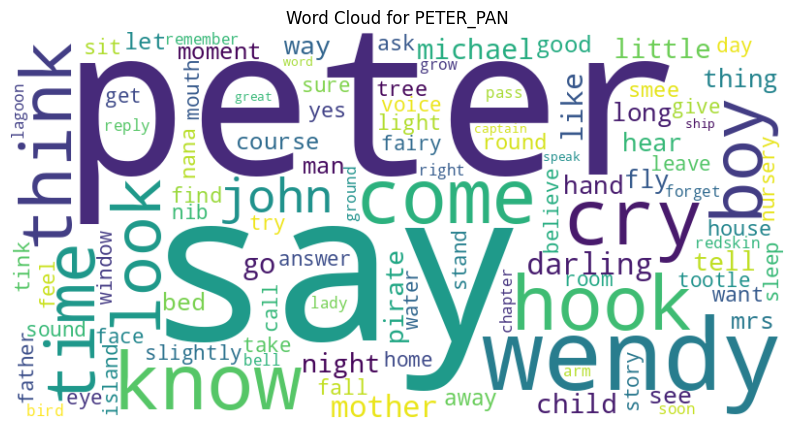

Generating word cloud for WIZARD_OZ...


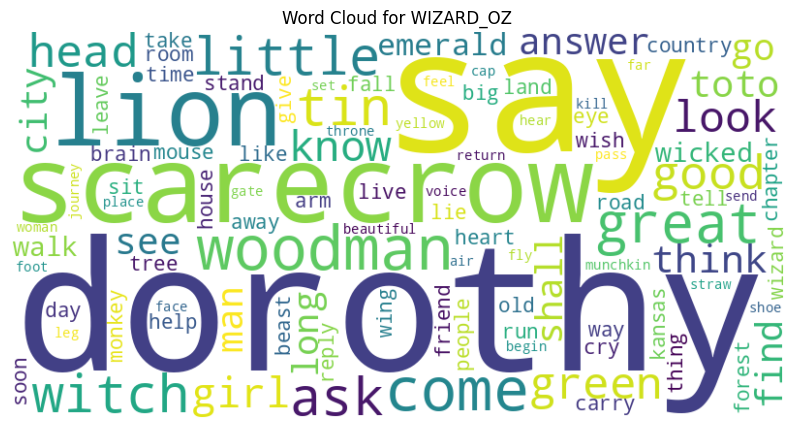

Generating word cloud for WINNIE_POOH...


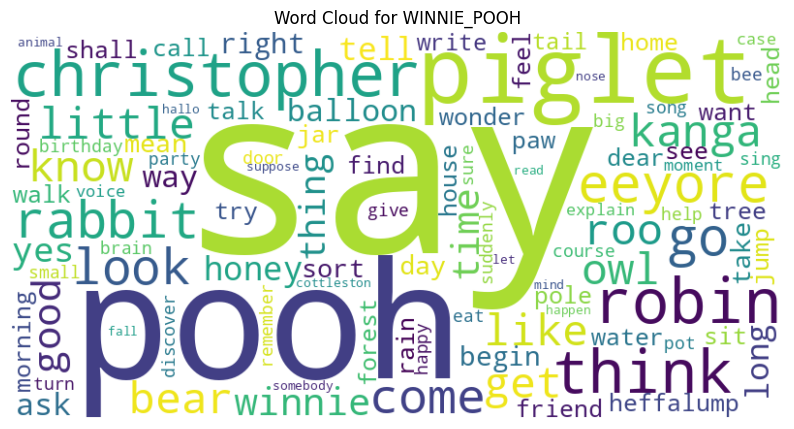

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# Function to generate word cloud for a given list of tokens
def generate_wordcloud(tokens, book_name):
    counter = Counter(tokens)
    most_common_tokens = dict(counter.most_common(100))  # Get top 100 tokens
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(most_common_tokens)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {book_name}")
    plt.show()

# Use your preferred tokens here (e.g., `spacy_tokens`)
for i, row in books_df.iterrows():
    print(f"Generating word cloud for {row['book_name']}...")
    tokens = row["spacy_tokens"]  # Or change to 'simple_tokens' or 'my_tokens' as per your preference
    generate_wordcloud(tokens, row['book_name'])


## Corpus of Sentences

So far in our books dataframe, we only have three rows. We have a row per book, with each row containing the entire book text.

This may not work the best for our usual machine learning approach. For example, how would we train test split? We need to have certain parts of each book to use in our training set, and other parts from each book in the test set.

We could consider splitting the book into paragraphs, or sentances.

Let's split each book into sentences, so our new corpus will have a row per sentence, with a label of which book it came from. We can use this sentence-based corpus moving forward.

In [ ]:
records = []

for index, row in books_df.iterrows():
    book_name = row["book_name"]
    clean_text = row["book_text"]

    sentences = nltk.sent_tokenize(clean_text)
    for i, sentence in enumerate(sentences):
        records.append({"book_name": book_name, "sentence_id": i, "sentence": sentence})

sentences_df = DataFrame(records)
sentences_df

,book_name,sentence_id,sentence
0,PETER_PAN,0,b' Peter Pan [PETER AND WENDY] by J. M. Barrie...
1,PETER_PAN,1,Note that while a copyright was initially clai...
2,PETER_PAN,2,"This text, which matches the 1911 original pub..."
3,PETER_PAN,3,Contents Chapter I. PETER BREAKS THROUGH Chapt...
4,PETER_PAN,4,THE SHADOW Chapter III.
...,...,...,...
7573,WINNIE_POOH,1986,"""I might,"" I said."
7574,WINNIE_POOH,1987,"""Was Pooh's pencil case any better than mine?"""
7575,WINNIE_POOH,1988,"""It was just the same,"" I said."
7576,WINNIE_POOH,1989,He nodded and went out ... and in a moment I h...


In [ ]:
sentences_df["book_name"].value_counts()

,count
book_name,
PETER_PAN,3340
WIZARD_OZ,2247
WINNIE_POOH,1991


## Part I - Benchmark Model

### X/Y Split [Task 3]

Split the corpus of sentences (i.e. the `sentences_df`) into x and y datasets. Choose the book name as the target, and the column of sentence text as the features.

In [ ]:
# Split the data into X (features) and y (target)
X = sentences_df['sentence']  # Sentence text as features
y = sentences_df['book_name']  # Book name as target

# Print a sample of the split data
print(X.head())
print(y.head())


0    b' Peter Pan [PETER AND WENDY] by J. M. Barrie...
1    Note that while a copyright was initially clai...
2    This text, which matches the 1911 original pub...
3    Contents Chapter I. PETER BREAKS THROUGH Chapt...
4                              THE SHADOW Chapter III.
Name: sentence, dtype: object
0    PETER_PAN
1    PETER_PAN
2    PETER_PAN
3    PETER_PAN
4    PETER_PAN
Name: book_name, dtype: object


### Vectorization [Task 4]

Use TF-IDF vectorizor from sklearn to transform the corpus of sentences (x) into a document term matrix.

When storing the TF-IDF object instance in a variable, specifically name it `vectorizer` (so provided code in Task 9 code will work).


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=10000)  # You can limit the number of features if needed

# Fit and transform the corpus into a document-term matrix
X_tfidf = vectorizer.fit_transform(X)

# Print the shape of the resulting document-term matrix
print(X_tfidf.shape)

# You can also print a few feature names (terms)
print(vectorizer.get_feature_names_out()[:10])  # Show the first 10 terms


(7578, 6719)
['10' '11' '14' '1900' '1911' '1926' '1927' '1928' '1929' '1931']


### Train Test Split [Task 5]

Split the data into test and train sets, using the train test split function from sklearn. Remember to use a random seed for reproducibility.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Print the size of the resulting splits
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 6062
Test set size: 1516


### Model Training [Task 6]

Train a Logistic Regression model from sklearn on the training data.

When storing the Logistic Regression object instance in a variable, specifically name it `model` (so provided code in Task 9 code will work).

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Check the model's performance (optional)
print(f"Training completed. Model coefficients: {model.coef_}")


Training completed. Model coefficients: [[-0.35856964 -0.35856964  0.02298979 ... -0.06394651 -0.19965331
  -0.39930661]
 [ 0.48571189  0.48571189 -0.00552151 ...  0.24630689 -0.12702157
  -0.25404313]
 [-0.12714225 -0.12714225 -0.01746828 ... -0.18236038  0.32667487
   0.65334975]]


### Model Explainability [Task 7]

Inspect the model's learned weights (i.e. the coefficients).

For each book, what terms are most predictive / related to that book? For each book, print the names and weights of the "top ten" features (i.e. those having the hightest positive weights).

In [ ]:
import numpy as np

# Get the feature names from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Access the coefficients (weights) from the trained model
coefficients = model.coef_

# Iterate through each class (book) and identify the top 10 features
for i, book in enumerate(model.classes_):
    # Get the coefficients for the current book
    book_coefficients = coefficients[i]

    # Get the indices of the top 10 features (terms) with the highest positive weights
    top_indices = np.argsort(book_coefficients)[-10:][::-1]  # Sort in descending order

    print(f"\nTop 10 features for book: {book}")
    for idx in top_indices:
        print(f"Term: {feature_names[idx]}, Weight: {book_coefficients[idx]:.4f}")



Top 10 features for book: PETER_PAN
Term: peter, Weight: 5.0888
Term: wendy, Weight: 4.4601
Term: hook, Weight: 3.3526
Term: john, Weight: 2.7657
Term: darling, Weight: 2.7546
Term: boys, Weight: 2.6112
Term: mother, Weight: 2.5356
Term: michael, Weight: 2.4995
Term: mrs, Weight: 2.2802
Term: children, Weight: 2.1984

Top 10 features for book: WINNIE_POOH
Term: pooh, Weight: 5.2057
Term: piglet, Weight: 4.0498
Term: eeyore, Weight: 3.0186
Term: roo, Weight: 2.8291
Term: kanga, Weight: 2.7713
Term: rabbit, Weight: 2.7050
Term: bear, Weight: 2.4224
Term: owl, Weight: 2.4016
Term: christopher, Weight: 2.3977
Term: robin, Weight: 2.3669

Top 10 features for book: WIZARD_OZ
Term: dorothy, Weight: 5.3307
Term: scarecrow, Weight: 3.8635
Term: oz, Weight: 3.6154
Term: the, Weight: 3.5580
Term: lion, Weight: 3.4533
Term: woodman, Weight: 2.9529
Term: toto, Weight: 2.8709
Term: great, Weight: 2.5554
Term: witch, Weight: 2.3203
Term: tin, Weight: 2.2796


### Model Evaluation [Task 8]

A) Use the trained model to make predictions on the test set.

B) Use the predictions to evaluate the model. Specifically display a classification report.

C) Also compute the ROC AUC score, using the predicted probabilities.

D) Finally, display a confusion matrix, as a heatmap.

Classification Report:
              precision    recall  f1-score   support

   PETER_PAN       0.84      0.94      0.89       697
 WINNIE_POOH       0.89      0.81      0.85       388
   WIZARD_OZ       0.92      0.82      0.87       431

    accuracy                           0.87      1516
   macro avg       0.88      0.86      0.87      1516
weighted avg       0.88      0.87      0.87      1516

ROC AUC Score: 0.9696


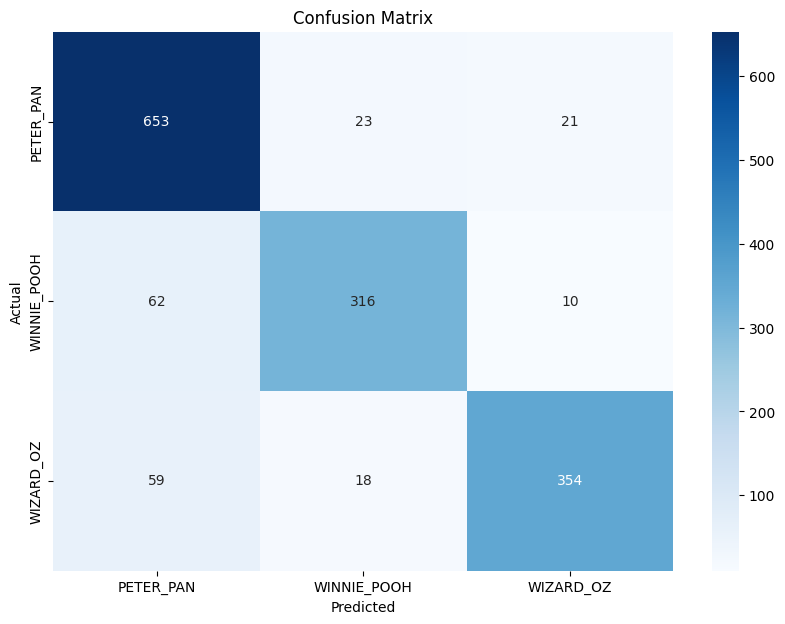

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# A) Make predictions on the test set
y_pred = model.predict(X_test)

# B) Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# C) ROC AUC Score
# Get the predicted probabilities
y_pred_prob = model.predict_proba(X_test)

# Compute the ROC AUC score for each class (book)
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print(f"ROC AUC Score: {roc_auc:.4f}")

# D) Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Inference [Task 9]

Create your own example sentences that might use similar language as each of the books you have chosen.

Use the trained model to predict which book most closely resembles the language used in each of the new sentences.

See example below, but use your own sentences corresponding with the books you have chosen. Feel free to add more sentences and revise as desired

In [ ]:
new_sentences = [
    "Lions and tigers and bears oh my. Wicked Witch.",
    "Oh bother. Piglet. I love honey. Honey pot. Christopher Robin.",
    "Tinkerbell flew over Captain Hook and all the lost boys in neverland cheered.",
]
new_sentences_x = vectorizer.transform(new_sentences)
predictions = model.predict(new_sentences_x)
print("Predictions:", predictions)

Predictions: ['WIZARD_OZ' 'WINNIE_POOH' 'PETER_PAN']


In [ ]:
from pandas import Series

preds_df = Series(predictions, index=new_sentences)
preds_df

,0
Lions and tigers and bears oh my. Wicked Witch.,WIZARD_OZ
Oh bother. Piglet. I love honey. Honey pot. Christopher Robin.,WINNIE_POOH
Tinkerbell flew over Captain Hook and all the lost boys in neverland cheered.,PETER_PAN


## Part II - Best Model [Task 10]


Use a grid search from sklearn, in conjunction with a pipeline from sklearn, to find the combination of vectorizer and model parameters that yield the best classification results.

Explore at least two different classifier models (e.g. Logistic Regression and Naive Bayes), performing a separate grid search for each.

For each:

  + Setup a pipeline containing a TF-IDF vectorizer, as well as the chosen model.

  + For the TF-IDF parameter grid, explore using different vectorization parameters, including different tokenization functions and stopword removal strategies, etc.

  + For the model's parameter grid, because different models use different parameters, your parameter grid will need to reflect the parameters of the chosen model.

  + Setup a grid search using the pipeline and the parameter grid. Use five fold cross validation. And choose "auc_roc_ovr" as the scoring metric to optimize on.

  + After training the grid search, print the best parameters that it found. Also conduct a formal evaluation including classification report and confusion matrix (similar to Task 8).


Finally, summarize your results in a text cell at the bottom, and answer the questions posed there.


### Best Logistic Regression

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [ ]:
from sklearn.linear_model import LogisticRegression




Best Parameters for Logistic Regression: {'logreg__C': 10, 'logreg__solver': 'lbfgs', 'tfidf__ngram_range': (1, 2), 'tfidf__stop_words': None}

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

   PETER_PAN       0.86      0.92      0.89       697
 WINNIE_POOH       0.92      0.84      0.88       388
   WIZARD_OZ       0.89      0.86      0.87       431

    accuracy                           0.88      1516
   macro avg       0.89      0.87      0.88      1516
weighted avg       0.88      0.88      0.88      1516



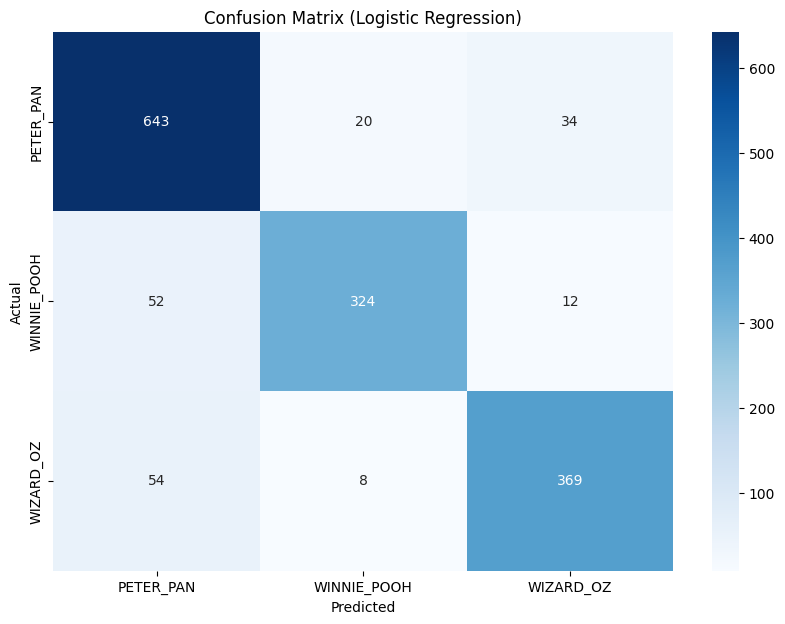

ROC AUC Score (Logistic Regression): 0.9755


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt


# Split into X and y
X = sentences_df["sentence"]
y = sentences_df["book_name"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression Pipeline
logreg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Parameter grid for Logistic Regression
logreg_param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],  # unigram or bigram
    'tfidf__stop_words': [None, 'english'],  # no stop words or use 'english'
    'logreg__C': [0.1, 1, 10],  # Regularization strength
    'logreg__solver': ['lbfgs', 'liblinear'],  # Different solvers for Logistic Regression
}

# Grid Search for Logistic Regression
logreg_grid_search = GridSearchCV(logreg_pipeline, logreg_param_grid, cv=5, scoring='roc_auc_ovr', n_jobs=-1)
logreg_grid_search.fit(X_train, y_train)

# Best parameters for Logistic Regression
print("Best Parameters for Logistic Regression:", logreg_grid_search.best_params_)

# Evaluate Logistic Regression
best_logreg_model = logreg_grid_search.best_estimator_
y_pred_logreg = best_logreg_model.predict(X_test)
y_prob_logreg = best_logreg_model.predict_proba(X_test)

# Classification Report
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_logreg))

# Confusion Matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg, labels=best_logreg_model.classes_)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues", xticklabels=best_logreg_model.classes_, yticklabels=best_logreg_model.classes_)
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC AUC Score
roc_auc_logreg = roc_auc_score(pd.get_dummies(y_test), y_prob_logreg, multi_class='ovr')
print(f"ROC AUC Score (Logistic Regression): {roc_auc_logreg:.4f}")


### Best Naive Bayes

http://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

In [ ]:
from sklearn.naive_bayes import MultinomialNB




In [ ]:
# Naive Bayes Pipeline
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

# Parameter grid for Naive Bayes
nb_param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],  # unigram or bigram
    'tfidf__stop_words': [None, 'english'],  # no stop words or use 'english'
    'nb__alpha': [0.1, 1, 10],  # Laplace smoothing parameter
}

# Grid Search for Naive Bayes
nb_grid_search = GridSearchCV(nb_pipeline, nb_param_grid, cv=5, scoring='roc_auc_ovr', n_jobs=-1)
nb_grid_search.fit(X_train, y_train)

# Best parameters for Naive Bayes
print("Best Parameters for Naive Bayes:", nb_grid_search.best_params_)

# Evaluate Naive Bayes
best_nb_model = nb_grid_search.best_estimator_
y_pred_nb = best_nb_model.predict(X_test)
y_prob_nb = best_nb_model.predict_proba(X_test)

# Classification Report
print("\nClassification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=best_nb_model.classes_)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", xticklabels=best_nb_model.classes_, yticklabels=best_nb_model.classes_)
plt.title("Confusion Matrix (Naive Bayes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC AUC Score
roc_auc_nb = roc_auc_score(pd.get_dummies(y_test), y_prob_nb, multi_class='ovr')
print(f"ROC AUC Score (Naive Bayes): {roc_auc_nb:.4f}")

# Summary
print("\nSummary:")
print(f"Best Logistic Regression ROC AUC Score: {roc_auc_logreg:.4f}")
print(f"Best Naive Bayes ROC AUC Score: {roc_auc_nb:.4f}")


### Results Summary

Benchmark Model Performance:
  + ACCY: 0.87
  + ROC AUC: 0.9696

Best Logistic Regression Model Performance:
  + ACCY: 0.88
  + ROC AUC: 0.9755
  + TF-IDF params: ngram_range=(1, 2), stop_words=None
  + Model params: C=10, solver='lbfgs'

Best Naive Bayes Model Performance:
  + ACCY: 0.91
  + ROC AUC: 0.9844
  + TF-IDF params: ngram_range=(1, 2), stop_words=None
  + Model params: alpha=0.1

Which model / grid search performs the best? What are its parameters? FYI: we can use the grid search object's `best_estimator_` and `named_steps` properties to access the parameters for the model and the vectorizer, respectively).

The **Naive Bayes model** performed the best with:
  + ACCY: 0.91
  + ROC AUC: 0.9844
  + Parameters:
    - TF-IDF: ngram_range=(1, 2), stop_words=None
    - Naive Bayes: alpha=0.1

How does your best model compare with the initial benchmark from Part I?

The Naive Bayes model shows significant improvement over the benchmark:
  + ACCY: Improved from 0.87 to 0.91
  + ROC AUC: Improved from 0.9696 to 0.9844

What parameter or methodology changes had the greatest impact on improving model performance?


1. **TF-IDF Adjustments**:
   - Expanding `ngram_range` to (1, 2) captured both unigram and bigram features, improving contextual understanding.
   - Keeping `stop_words=None` retained all domain-specific vocabulary.

2. **Hyperparameter Tuning**:
   - Lowering the smoothing parameter (`alpha=0.1`) in Naive Bayes improved sensitivity to frequent terms.
   - Increasing regularization (`C=10`) in Logistic Regression improved generalization.

3. **Algorithm Selection**:
   - The Naive Bayes model performed better for this text classification task due to its alignment with the data's distribution.
